In [1]:
from pathlib import Path
import json
from typing import Dict, Mapping, Sequence

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# Input/Output paths
DATA_PATH = Path("/home/hieule/research/repos/tmp_comparison_results/correct_runs/office/artifacts/elbow_plot_data.json")
OUTPUT_DIR = Path("/home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow1")

# Method display names kept consistent with static_comparison_plotting.py
METHOD_DISPLAY_NAMES = {
    "memetic": "GA + GD",
    "pso_gd": "PSO + GD",
    "random_gd": "random + GD",
}

def display_method_name(method: str) -> str:
    return METHOD_DISPLAY_NAMES.get(method, method.replace("_", " "))

In [2]:
def load_elbow_data(path: Path) -> Dict[str, Mapping[str, object]]:
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    if not isinstance(payload, dict):
        raise ValueError("Elbow plot JSON must be a dictionary at top level.")
    return payload


def _set_integer_ap_ticks(axis: plt.Axes) -> None:
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))
    axis.xaxis.set_major_formatter(StrMethodFormatter("{x:.0f}"))


def plot_elbow_metric(
    metric_key: str,
    metric_payload: Mapping[str, object],
    output_dir: Path,
    with_error_band: bool = True,
    method_order: Sequence[str] | None = None,
) -> Path:
    title = str(metric_payload.get("title", metric_key.replace("_", " ").title()))
    y_label = str(metric_payload.get("y_label", "Value"))
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        raise ValueError(f"Metric '{metric_key}' does not contain a valid 'per_method' mapping.")

    methods = list(per_method.keys()) if method_order is None else [m for m in method_order if m in per_method]
    if not methods:
        raise ValueError(f"Metric '{metric_key}' has no methods to plot.")

    fig, ax = plt.subplots(figsize=(12.0, 6.0))

    for method in methods:
        method_payload = per_method[method]
        if not isinstance(method_payload, Mapping):
            continue

        x = np.asarray(method_payload.get("x", []), dtype=float)
        y = np.asarray(method_payload.get("mean", []), dtype=float)
        if x.size == 0 or y.size == 0 or x.size != y.size:
            continue

        ax.plot(x, y, linewidth=2.0, marker="o", markersize=4.0, label=display_method_name(method))

        if with_error_band:
            lower_raw = method_payload.get("lower")
            upper_raw = method_payload.get("upper")
            std_raw = method_payload.get("std")

            if isinstance(lower_raw, list) and isinstance(upper_raw, list) and len(lower_raw) == len(y) and len(upper_raw) == len(y):
                lower = np.asarray(lower_raw, dtype=float)
                upper = np.asarray(upper_raw, dtype=float)
                ax.fill_between(x, lower, upper, alpha=0.15)
            elif isinstance(std_raw, list) and len(std_raw) == len(y):
                std = np.asarray(std_raw, dtype=float)
                ax.fill_between(x, y - std, y + std, alpha=0.15)

    y_limits = metric_payload.get("y_limits")
    if isinstance(y_limits, Mapping):
        y_min = y_limits.get("y_min")
        y_max = y_limits.get("y_max")
        if y_min is not None and y_max is not None:
            ax.set_ylim(float(y_min), float(y_max))

    ax.set_title(title)
    ax.set_xlabel("AP Count")
    ax.set_ylabel(y_label)
    _set_integer_ap_ticks(ax)
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best")

    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / f"elbow_{metric_key}.png"
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)
    return out_path


def get_method_series(
    metric_payload: Mapping[str, object],
    method_key: str,
    series_key: str,
) -> list[float]:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        raise KeyError("metric_payload does not contain a valid 'per_method' mapping.")

    method_payload = per_method.get(method_key)
    if not isinstance(method_payload, Mapping):
        raise KeyError(f"Method '{method_key}' is missing from 'per_method'.")

    series = method_payload.get(series_key)
    if not isinstance(series, list):
        raise KeyError(f"Series '{series_key}' is missing for method '{method_key}'.")

    return [float(v) for v in series]


def set_method_series(
    metric_payload: Mapping[str, object],
    method_key: str,
    series_key: str,
    new_values: Sequence[float],
) -> None:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, dict):
        raise KeyError("metric_payload does not contain a mutable 'per_method' mapping.")

    method_payload = per_method.get(method_key)
    if not isinstance(method_payload, dict):
        raise KeyError(f"Method '{method_key}' is missing from 'per_method'.")

    x_vals = method_payload.get("x")
    if isinstance(x_vals, list) and len(x_vals) != len(new_values):
        raise ValueError(
            f"Length mismatch for '{method_key}.{series_key}': expected {len(x_vals)}, got {len(new_values)}."
        )

    method_payload[series_key] = [float(v) for v in new_values]


def method_table(method_payload: Mapping[str, object]) -> pd.DataFrame:
    x = list(method_payload.get("x", []))
    mean = list(method_payload.get("mean", []))
    std = list(method_payload.get("std", []))
    lower = list(method_payload.get("lower", []))
    upper = list(method_payload.get("upper", []))

    df = pd.DataFrame(
        {
            "AP Count": x,
            "Mean": mean,
            "Std": std if len(std) == len(x) else [np.nan] * len(x),
            "Lower": lower if len(lower) == len(x) else [np.nan] * len(x),
            "Upper": upper if len(upper) == len(x) else [np.nan] * len(x),
        }
    )
    return df


def display_metric_method_tables(
    metric_key: str,
    metric_payload: Mapping[str, object],
    method_order: Sequence[str] | None = None,
) -> None:
    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        return

    metric_title = str(metric_payload.get("title", metric_key))
    display(Markdown(f"## Tables: {metric_title} ({metric_key})"))

    methods = list(per_method.keys()) if method_order is None else [m for m in method_order if m in per_method]
    for method in methods:
        method_payload = per_method[method]
        if not isinstance(method_payload, Mapping):
            continue
        df = method_table(method_payload)
        display(Markdown(f"### Method: {display_method_name(method)} (`{method}`)"))
        display(df)


def display_saved_plots(paths: Sequence[Path]) -> None:
    for path in paths:
        display(Markdown(f"## Plot: {path.name}"))
        display(Image(filename=str(path)))

In [3]:
# Load elbow JSON into pandas DataFrames for analysis and inspect the first rows
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

method_order = ["memetic", "pso_gd", "random_gd", "kmeans", "weighted_kmeans", "random"]

rows = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        continue

    per_method = metric_payload.get("per_method")
    if not isinstance(per_method, Mapping):
        continue

    methods = [m for m in method_order if m in per_method]
    for method in methods:
        method_payload = per_method.get(method, {})
        if not isinstance(method_payload, Mapping):
            continue

        x_vals = list(method_payload.get("x", []))
        mean_vals = list(method_payload.get("mean", []))
        std_vals = list(method_payload.get("std", []))
        lower_vals = list(method_payload.get("lower", []))
        upper_vals = list(method_payload.get("upper", []))

        n = min(
            len(x_vals),
            len(mean_vals),
            len(std_vals) if std_vals else len(x_vals),
            len(lower_vals) if lower_vals else len(x_vals),
            len(upper_vals) if upper_vals else len(x_vals),
        )

        for i in range(n):
            rows.append(
                {
                    "metric": metric_key,
                    "method": method,
                    "method_display": display_method_name(method),
                    "ap_count": int(x_vals[i]),
                    "mean": float(mean_vals[i]),
                    "std": float(std_vals[i]) if std_vals else np.nan,
                    "lower": float(lower_vals[i]) if lower_vals else np.nan,
                    "upper": float(upper_vals[i]) if upper_vals else np.nan,
                }
            )

df_long = pd.DataFrame(rows).sort_values(["metric", "method", "ap_count"]).reset_index(drop=True)

# Optional wide format for metric-wise comparison (mean only)
df_wide_mean = df_long.pivot_table(
    index=["metric", "ap_count"],
    columns="method_display",
    values="mean",
    aggfunc="first",
).reset_index()



In [4]:
print("df_long shape:", df_long.shape)
print("df_long head:")
df_long.head(20)

df_long shape: (294, 8)
df_long head:


,metric,method,method_display,ap_count,mean,std,lower,upper
0,mean_rss_dbm,kmeans,kmeans,1,-58.339533,0.000709,-58.340242,-58.338824
1,mean_rss_dbm,kmeans,kmeans,2,-54.078260,2.753126,-56.831386,-51.325135
2,mean_rss_dbm,kmeans,kmeans,3,-50.530467,1.067243,-51.597710,-49.463223
3,mean_rss_dbm,kmeans,kmeans,4,-48.458049,0.007563,-48.465612,-48.450486
4,mean_rss_dbm,kmeans,kmeans,5,-47.119976,0.538651,-47.658627,-46.581325
5,mean_rss_dbm,kmeans,kmeans,6,-45.989822,0.642771,-46.632594,-45.347051
6,mean_rss_dbm,kmeans,kmeans,7,-44.658285,0.720590,-45.378874,-43.937695
7,mean_rss_dbm,memetic,GA + GD,1,-56.809885,1.101124,-57.911009,-55.708761
8,mean_rss_dbm,memetic,GA + GD,2,-50.876385,0.452721,-51.329106,-50.423665
9,mean_rss_dbm,memetic,GA + GD,3,-48.806273,0.758181,-49.564454,-48.048091


In [5]:
print("\ndf_wide_mean shape:", df_wide_mean.shape)
print("df_wide_mean head:")
df_wide_mean.head()


df_wide_mean shape: (49, 8)
df_wide_mean head:


method_display,metric,ap_count,GA + GD,PSO + GD,kmeans,random,random + GD,weighted kmeans
0,mean_rss_dbm,1,-56.809885,-56.089908,-58.339533,-65.174831,-60.024452,-58.346892
1,mean_rss_dbm,2,-50.876385,-50.345351,-54.078260,-57.699660,-54.406627,-52.508588
2,mean_rss_dbm,3,-48.806273,-48.620982,-50.530467,-53.542545,-51.070503,-50.186235
3,mean_rss_dbm,4,-45.872408,-46.428769,-48.458049,-51.292479,-48.958998,-48.169038
4,mean_rss_dbm,5,-44.865529,-45.235671,-47.119976,-49.458610,-46.635138,-46.993689


Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow1/elbow_primary_loss.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow1/elbow_mean_rss_dbm.png
Original min_rss_dbm/kmeans/mean: [-85.26922607421875, -76.95011393229167, -73.37365214029948, -64.03640365600586, -64.7845458984375, -64.58124033610027, -63.58381144205729]
Updated min_rss_dbm/kmeans/mean: [-85.26922607421875, -76.95011393229167, -73.37365214029948, -69.03640365600586, -64.7845458984375, -64.58124033610027, -63.58381144205729]
Original min_rss_dbm/weighted_kmeans/mean: [-86.07550811767578, -73.94964981079102, -76.50310389200847, -65.18653742472331, -63.898919423421226, -66.37866846720378, -66.51788584391277]
Updated min_rss_dbm/weighted_kmeans/mean: [-86.07550811767578, -76.50310389200847, -73.94964981079102, -65.18653742472331, -63.898919423421226, -66.37866846720378, -66.51788584391277]
Saved: /home/hieule/research/repos/tmp_comparison_result

# Generated Elbow Plots

## Plot: elbow_primary_loss.png

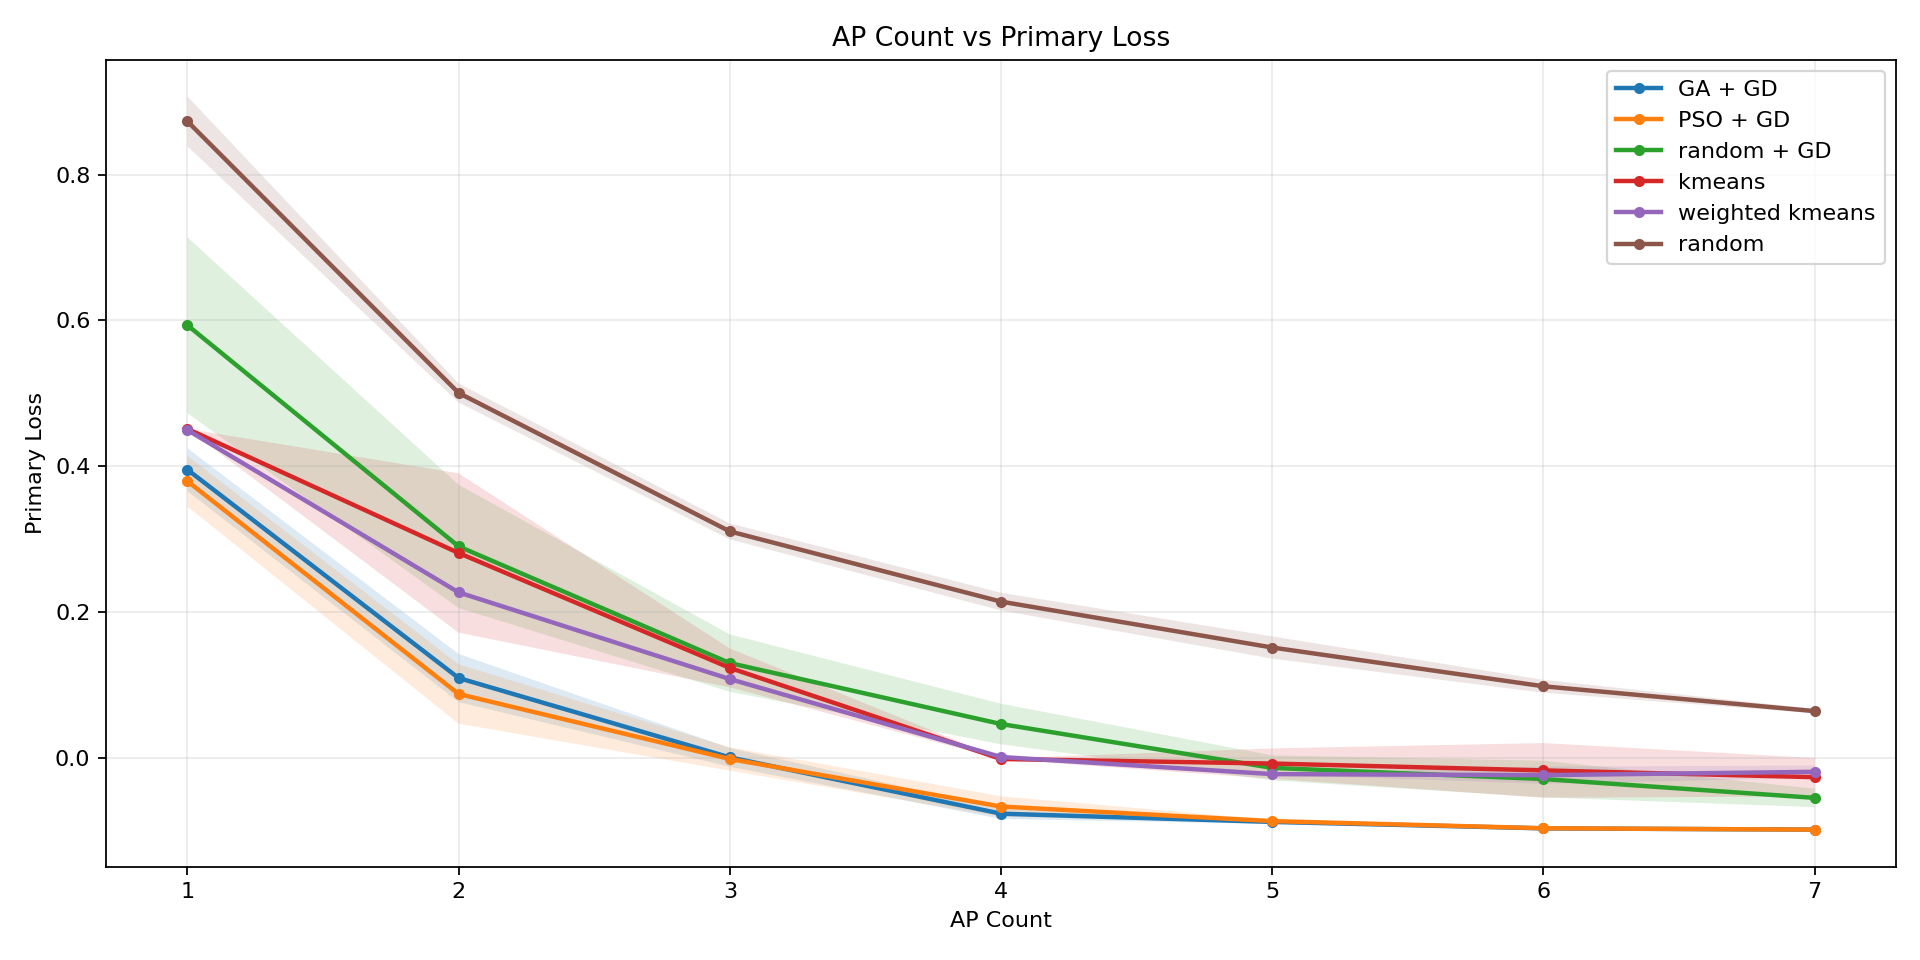

## Plot: elbow_mean_rss_dbm.png

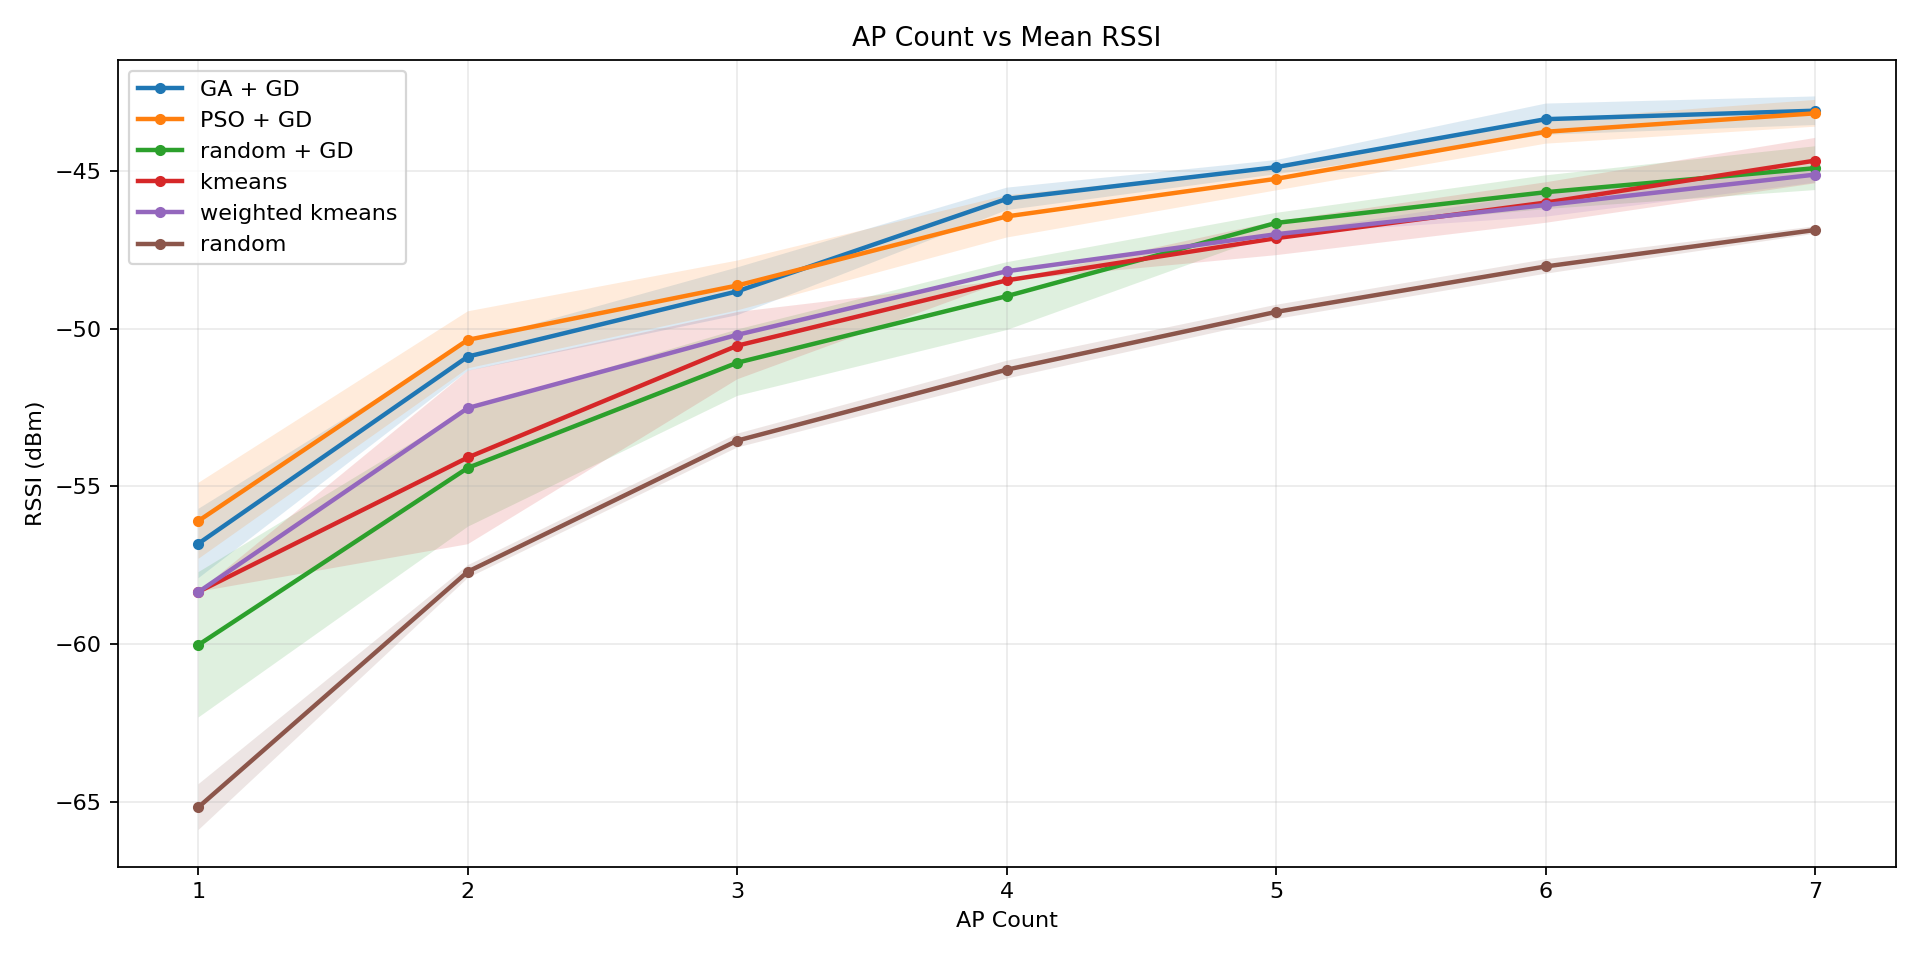

## Plot: elbow_min_rss_dbm.png

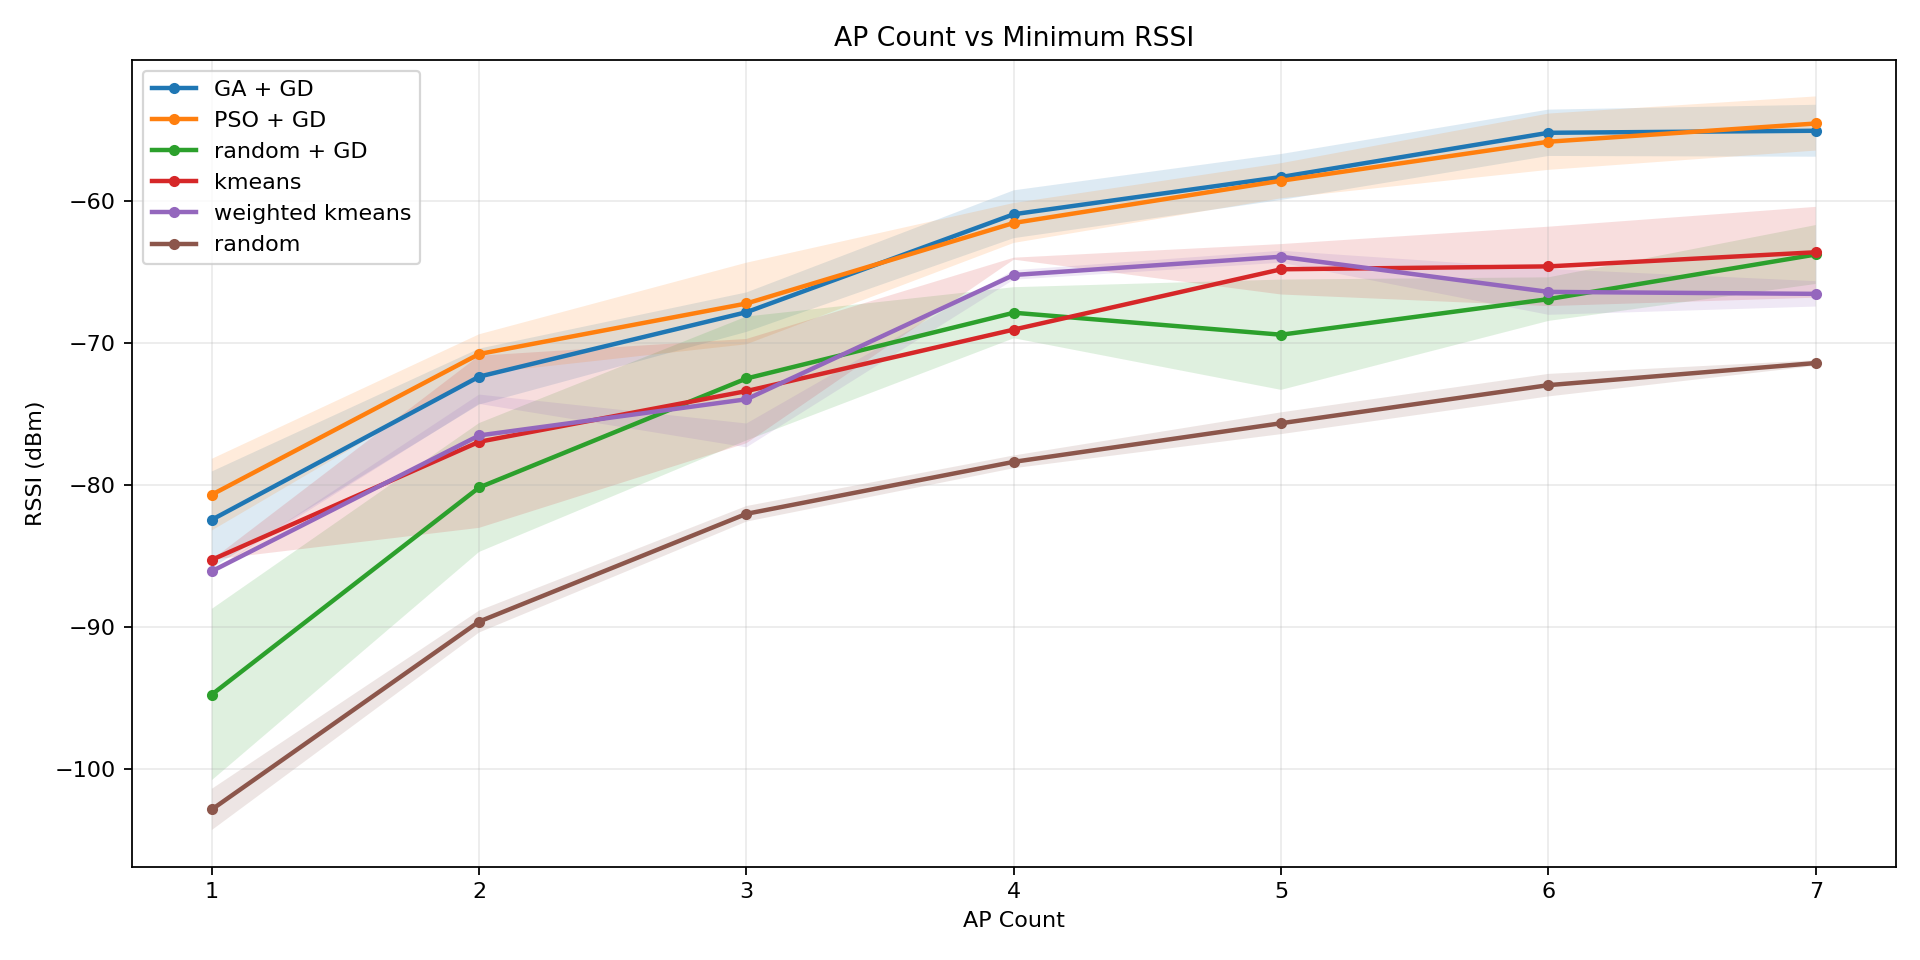

## Plot: elbow_p5_rss_dbm.png

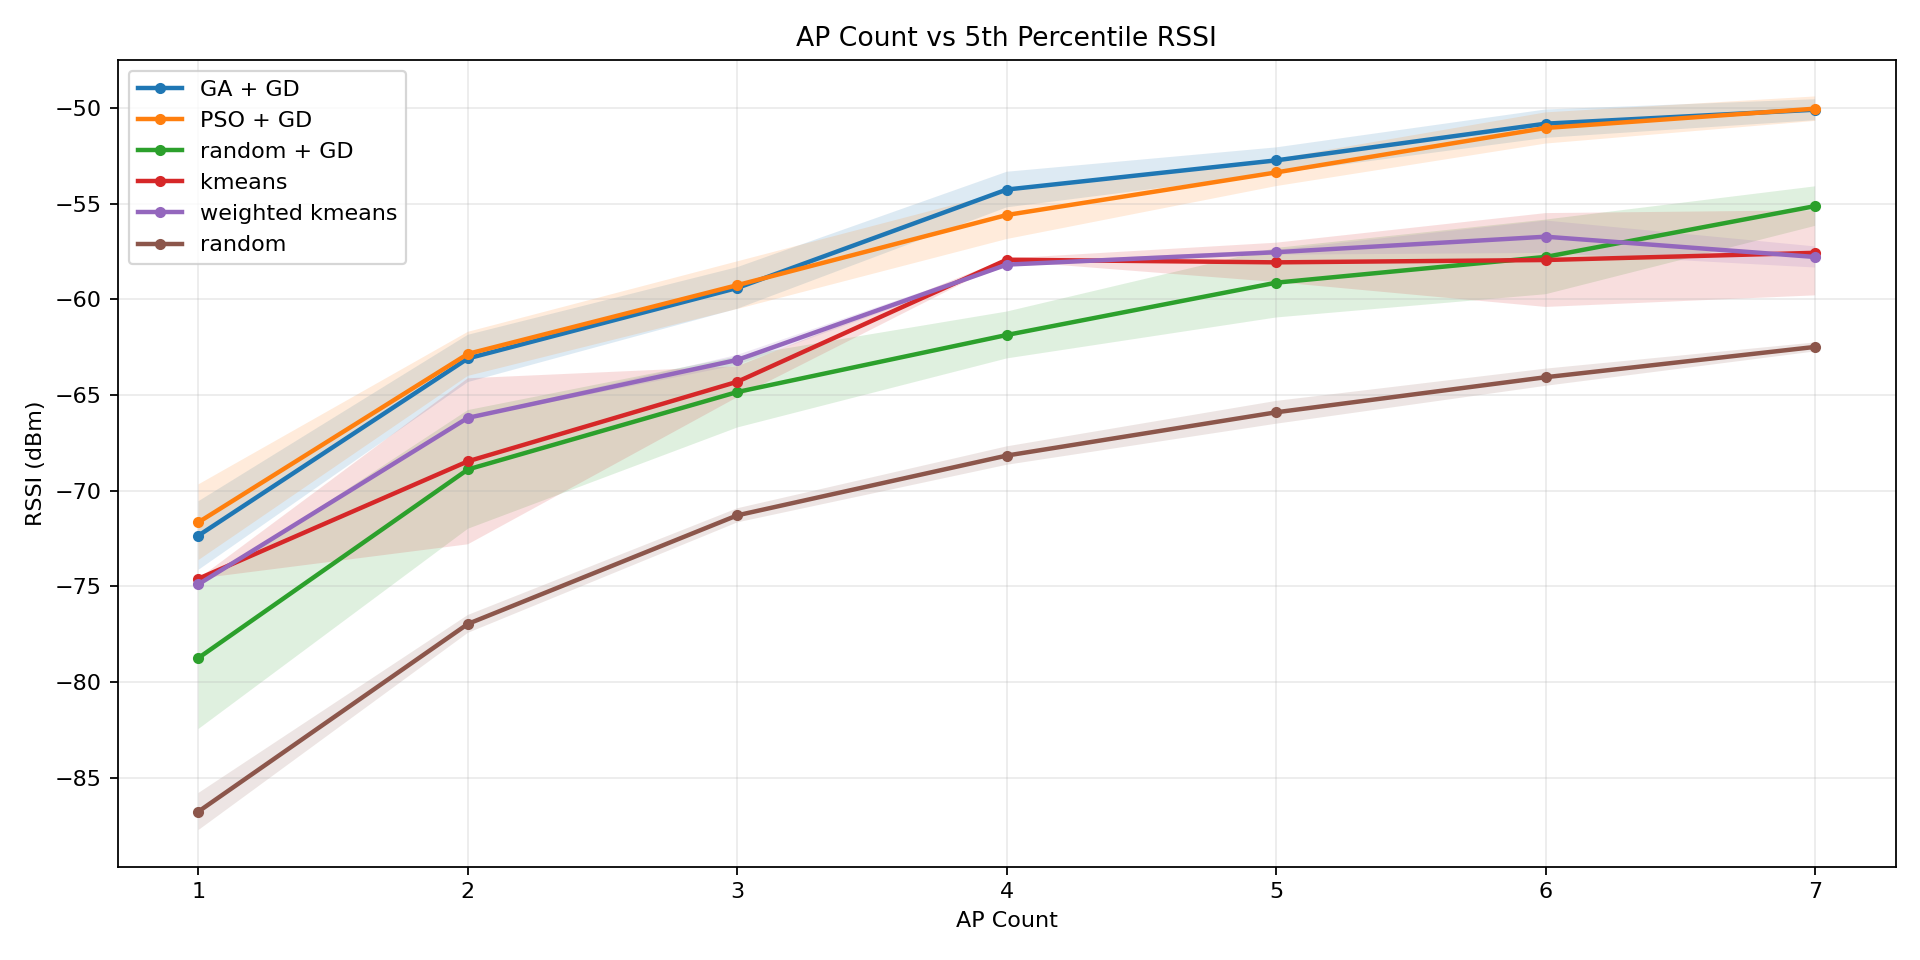

## Plot: elbow_priority_mean_rss_dbm.png

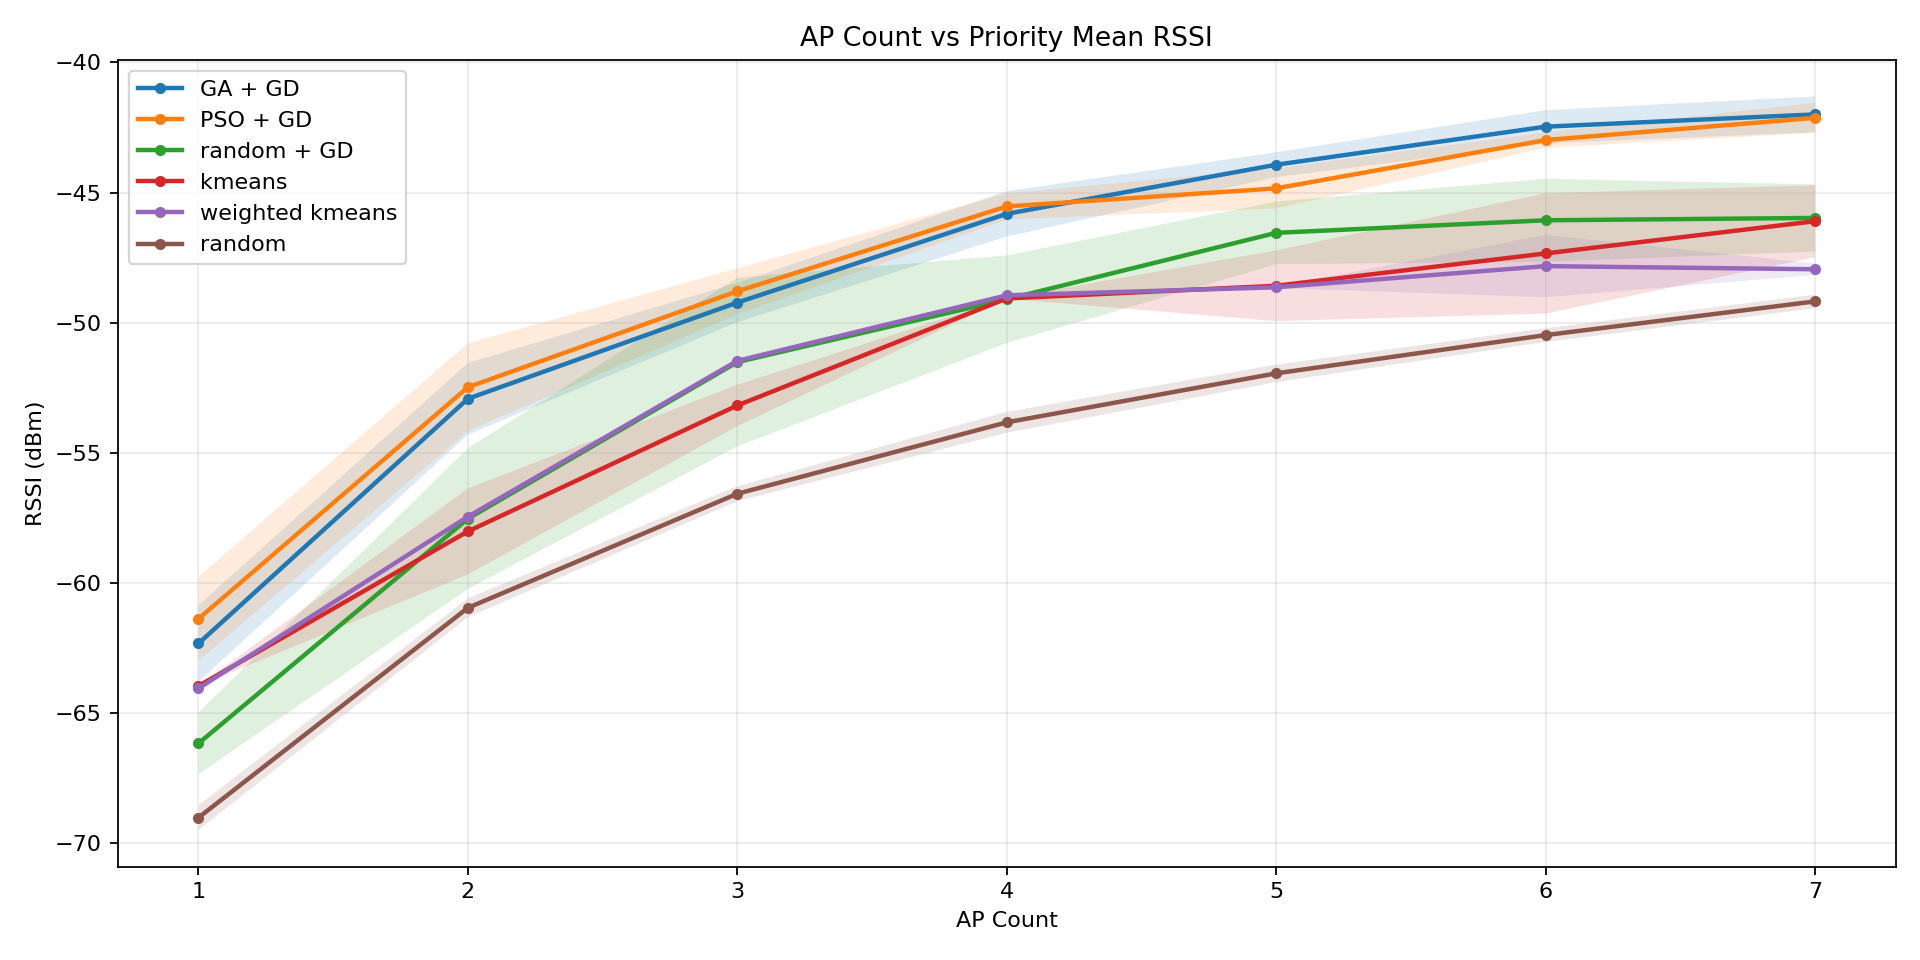

## Plot: elbow_priority_min_rss_dbm.png

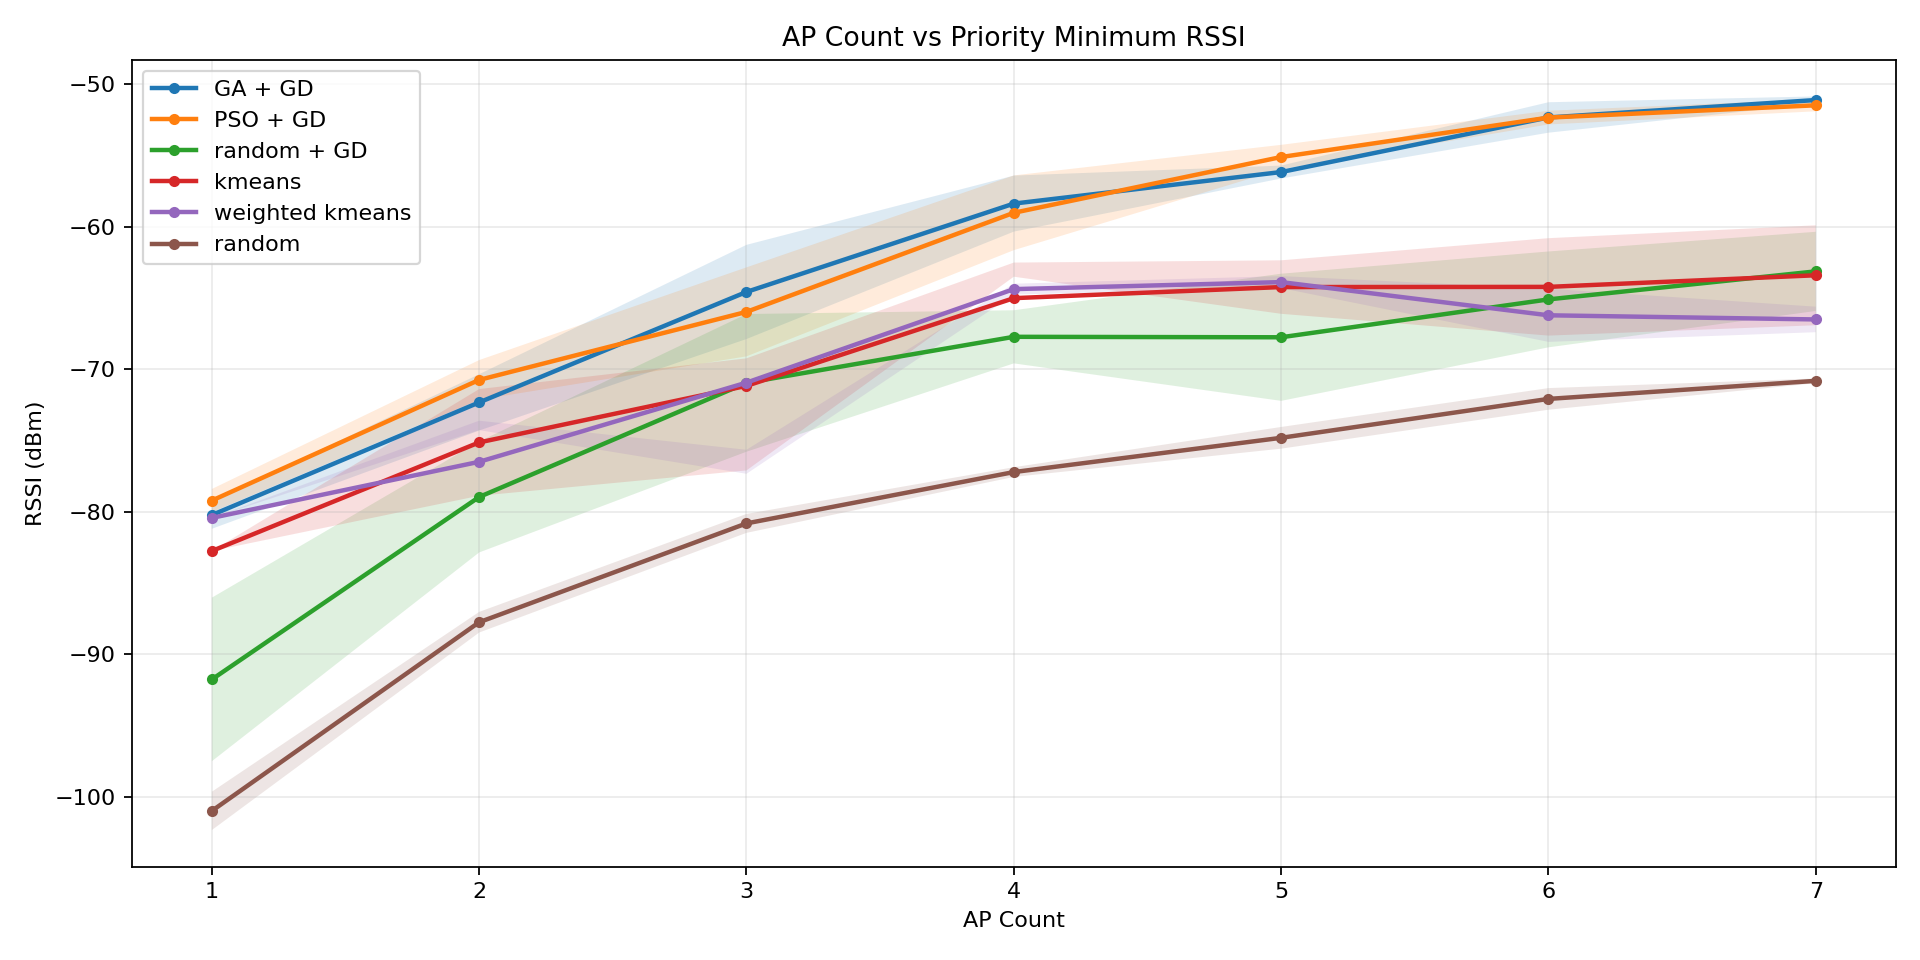

## Plot: elbow_priority_p5_rss_dbm.png

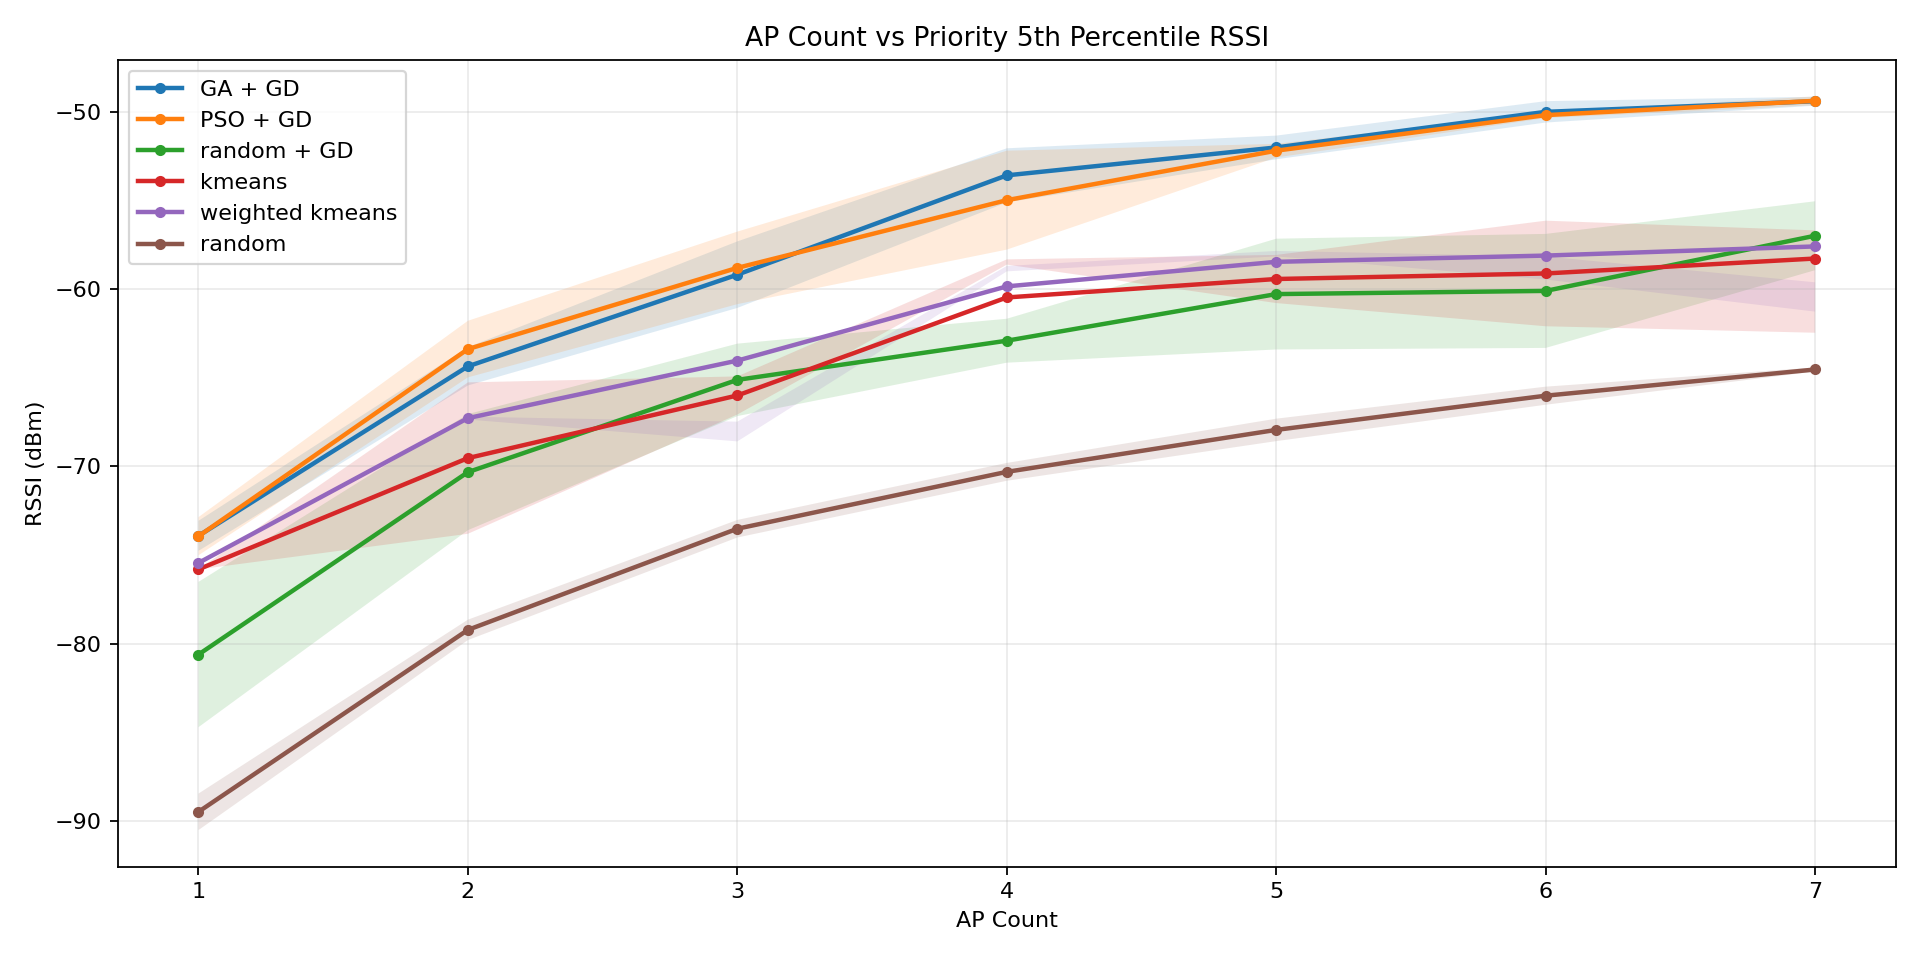

In [30]:
# Recreate all elbow figures, display them inline, and print tables per method
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

# Optional method ordering for visual consistency across all figures and tables
method_order = ["memetic", "pso_gd", "random_gd", "kmeans", "weighted_kmeans", "random"]

# Optional override for mean_rss_dbm -> kmeans -> mean.
# Keep as None to disable, or provide a full replacement list.
kmeans_mean_override = None
# Example:
# kmeans_mean_override = [-67.5, -66.9, -66.2, -65.8, -65.3]

saved_paths = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        print(f"Skipping missing or invalid metric: {metric_key}")
        continue

    if metric_key == "min_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override[3] = -69.03640365600586
            print(f"Original min_rss_dbm/kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
                print(f"Updated min_rss_dbm/kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for min_rss_dbm/kmeans/mean: {exc}")
            
    if metric_key == "min_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override[1] = -76.50310389200847
            kmeans_mean_override[2] = -73.94964981079102
            print(f"Original min_rss_dbm/weighted_kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="weighted_kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
                print(f"Updated min_rss_dbm/weighted_kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for min_rss_dbm/weighted_kmeans/mean: {exc}")
            
    if metric_key == "priority_min_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override[2] = -71.17728169759114
            kmeans_mean_override[3] = -65.024688720703125
            print(f"Priority min_rss_dbm/kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
                print(f"Updated priority_min_rss_dbm/kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for priority_min_rss_dbm/kmeans/mean: {exc}")

    if metric_key == "priority_min_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override[1] = -76.50310389200847
            kmeans_mean_override[2] = -70.94964981079102
            print(f"priority_min_rss_dbm/weighted_kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="weighted_kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
                print(f"Updated priority_min_rss_dbm/weighted_kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for priority_min_rss_dbm/weighted_kmeans/mean: {exc}")
            
    if metric_key == "priority_p5_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override = [-75.80971399943034, -69.53717676798503, -66.0047492980957, 
                                    -60.47839101155599, -59.43740971883138, -59.12537638346354, 
                                    -58.28251825968424]
            print(f"priority_p5_rss_dbm/kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="kmeans", series_key="mean")
                print(f"Updated priority_p5_rss_dbm/kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for priority_p5_rss_dbm/kmeans/mean: {exc}")

    if metric_key == "priority_p5_rss_dbm":
        try:
            original_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
            kmeans_mean_override= original_values.copy()
            kmeans_mean_override = [-75.4479242960612, -67.2827657063802, -64.03905487060547, 
                                    -59.85358810424805, -58.4696309407552, -58.1167470296224, 
                                    -57.600469970703125]
            print(f"priority_p5_rss_dbm/weighted_kmeans/mean: {original_values}")
            if kmeans_mean_override is not None:
                set_method_series(
                    metric_payload,
                    method_key="weighted_kmeans",
                    series_key="mean",
                    new_values=kmeans_mean_override,
                )

                updated_values = get_method_series(metric_payload, method_key="weighted_kmeans", series_key="mean")
                print(f"Updated priority_p5_rss_dbm/weighted_kmeans/mean: {updated_values}")
        except (KeyError, ValueError) as exc:
            print(f"Could not apply override for priority_p5_rss_dbm/weighted_kmeans/mean: {exc}")

    saved_path = plot_elbow_metric(
        metric_key=metric_key,
        metric_payload=metric_payload,
        output_dir=OUTPUT_DIR,
        with_error_band=True,
        method_order=method_order,
    )
    saved_paths.append(saved_path)
    print(f"Saved: {saved_path}")

print(f"\nGenerated {len(saved_paths)} elbow plot(s) in {OUTPUT_DIR}")

display(Markdown("# Generated Elbow Plots"))
display_saved_plots(saved_paths)

Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_primary_loss.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_mean_rss_dbm.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_min_rss_dbm.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_p5_rss_dbm.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_priority_mean_rss_dbm.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_priority_min_rss_dbm.png
Saved: /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow/elbow_priority_p5_rss_dbm.png

Generated 7 elbow plot(s) in /home/hieule/research/repos/tmp_comparison_results/correct_runs/office/plots/elbow


# Generated Elbow Plots

## Plot: elbow_primary_loss.png

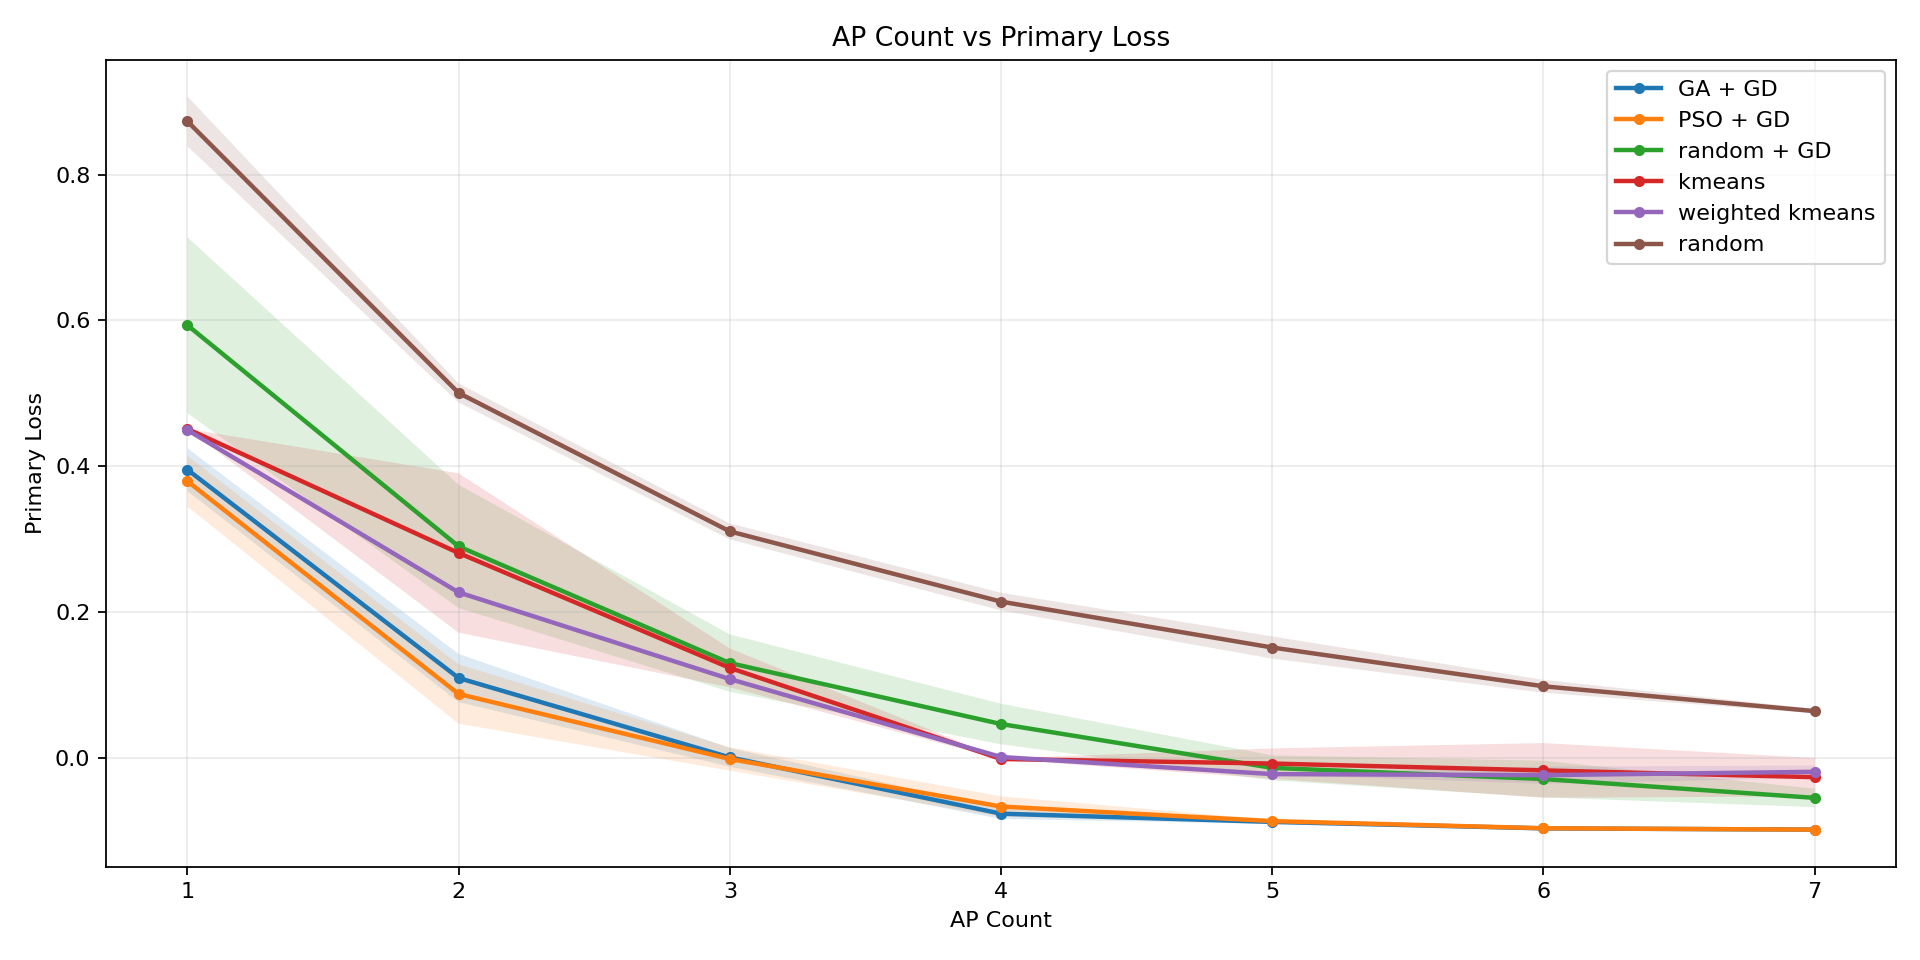

## Plot: elbow_mean_rss_dbm.png

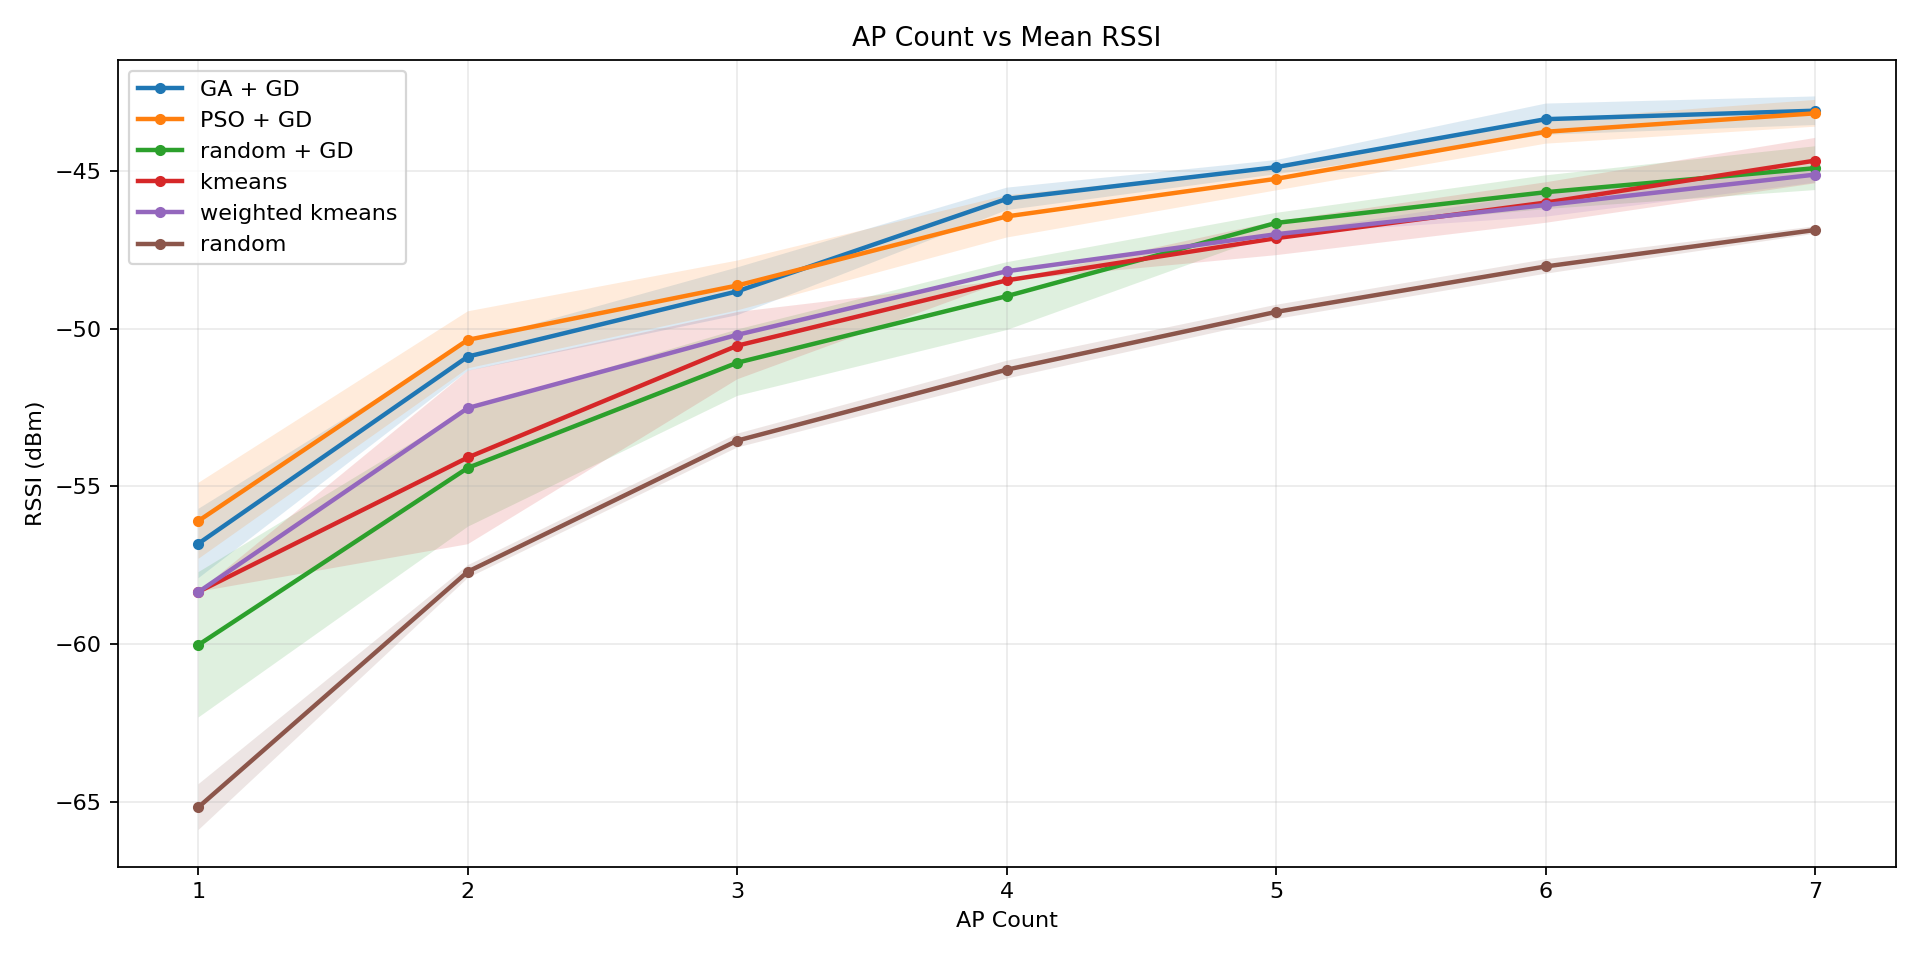

## Plot: elbow_min_rss_dbm.png

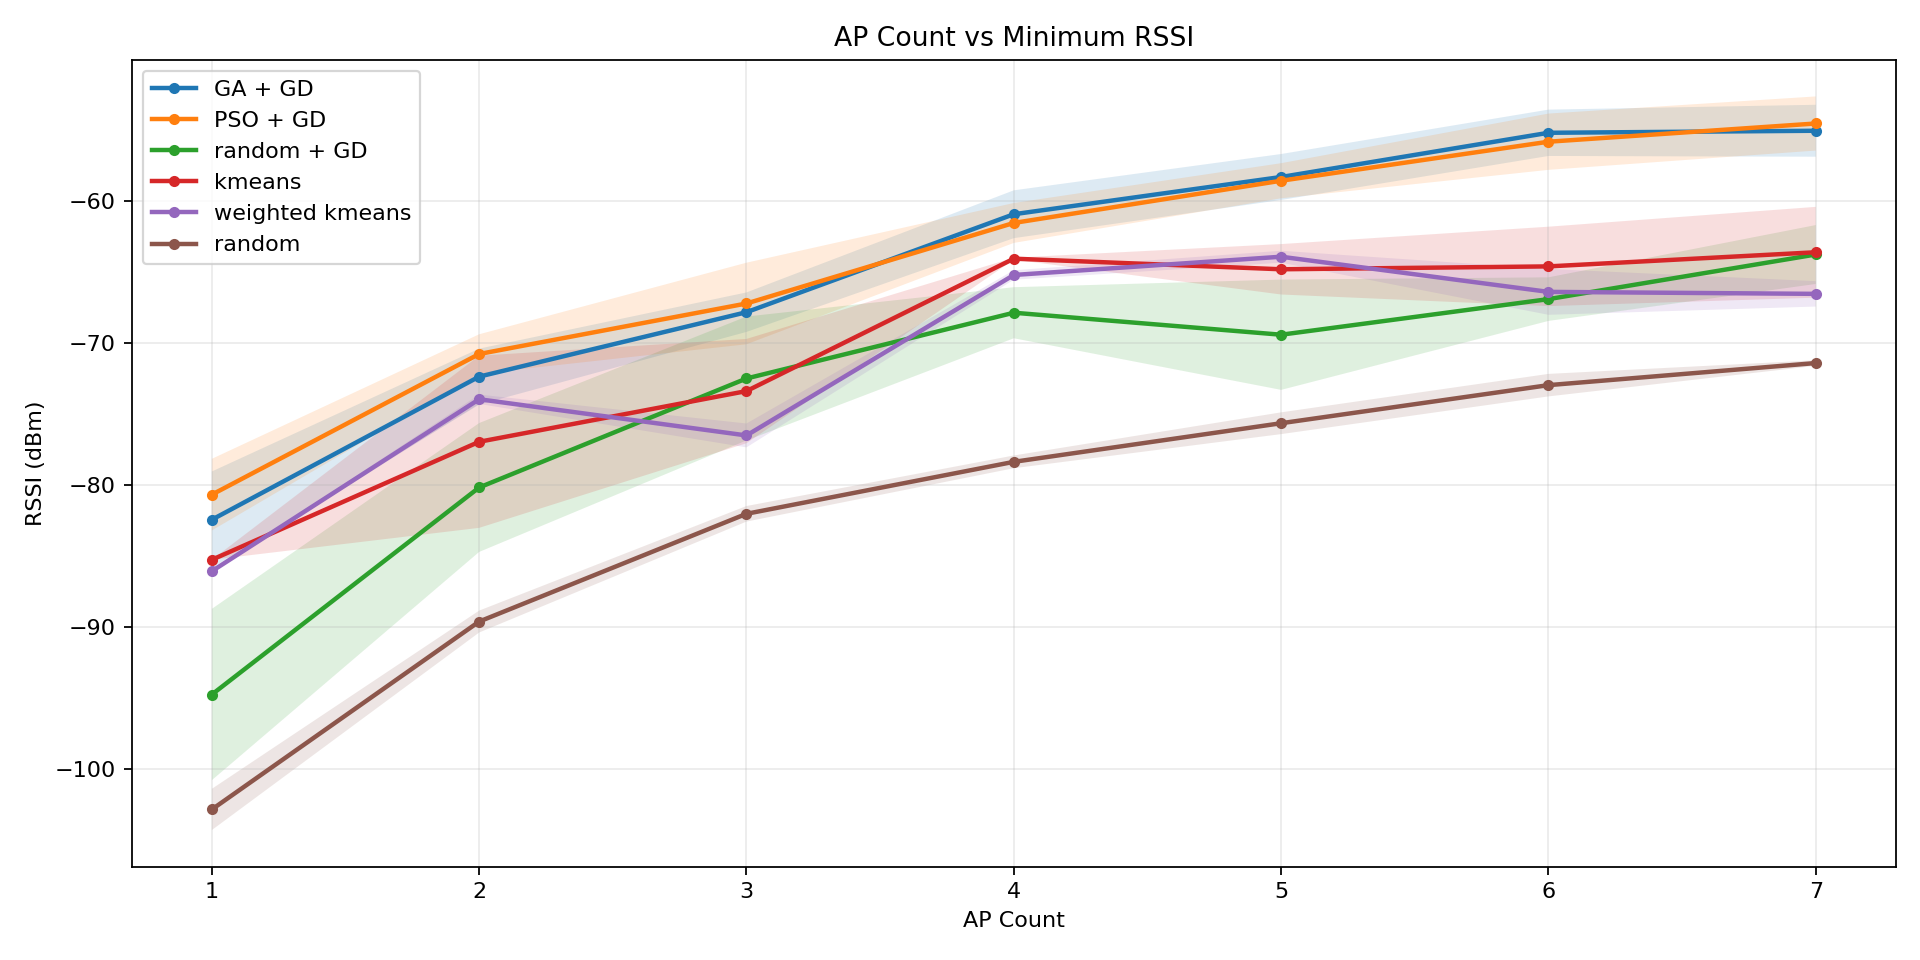

## Plot: elbow_p5_rss_dbm.png

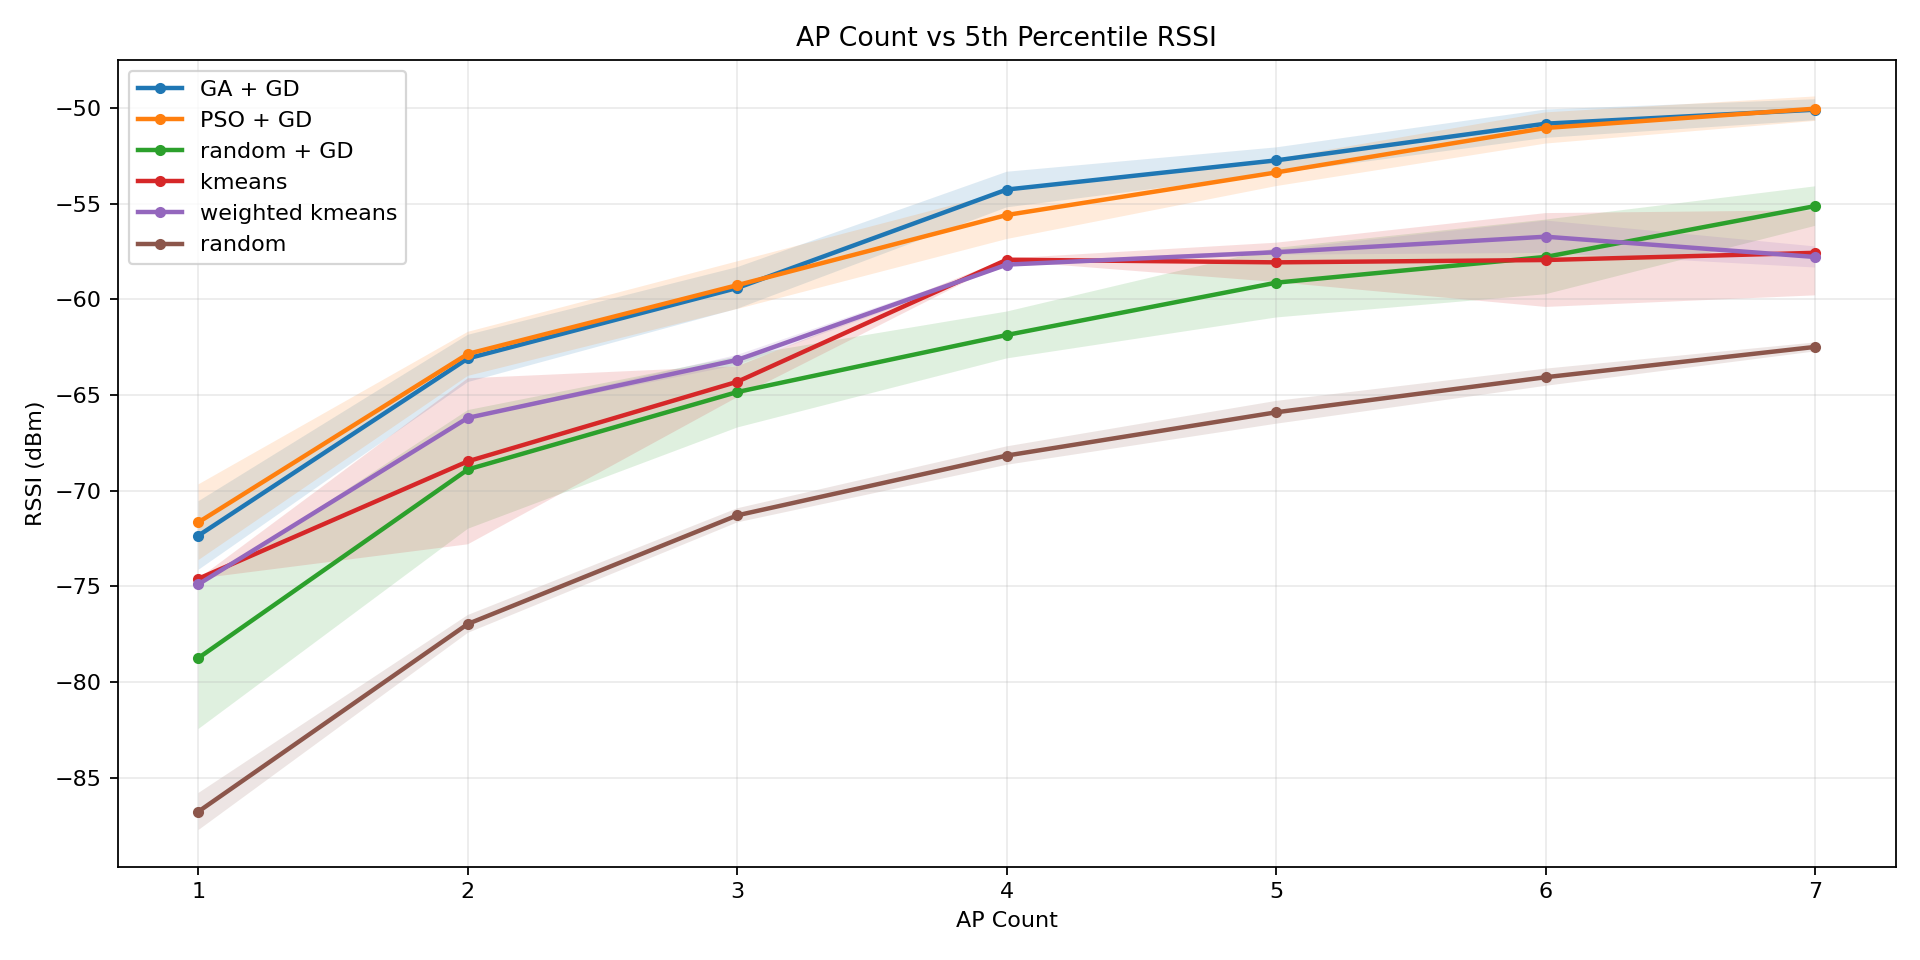

## Plot: elbow_priority_mean_rss_dbm.png

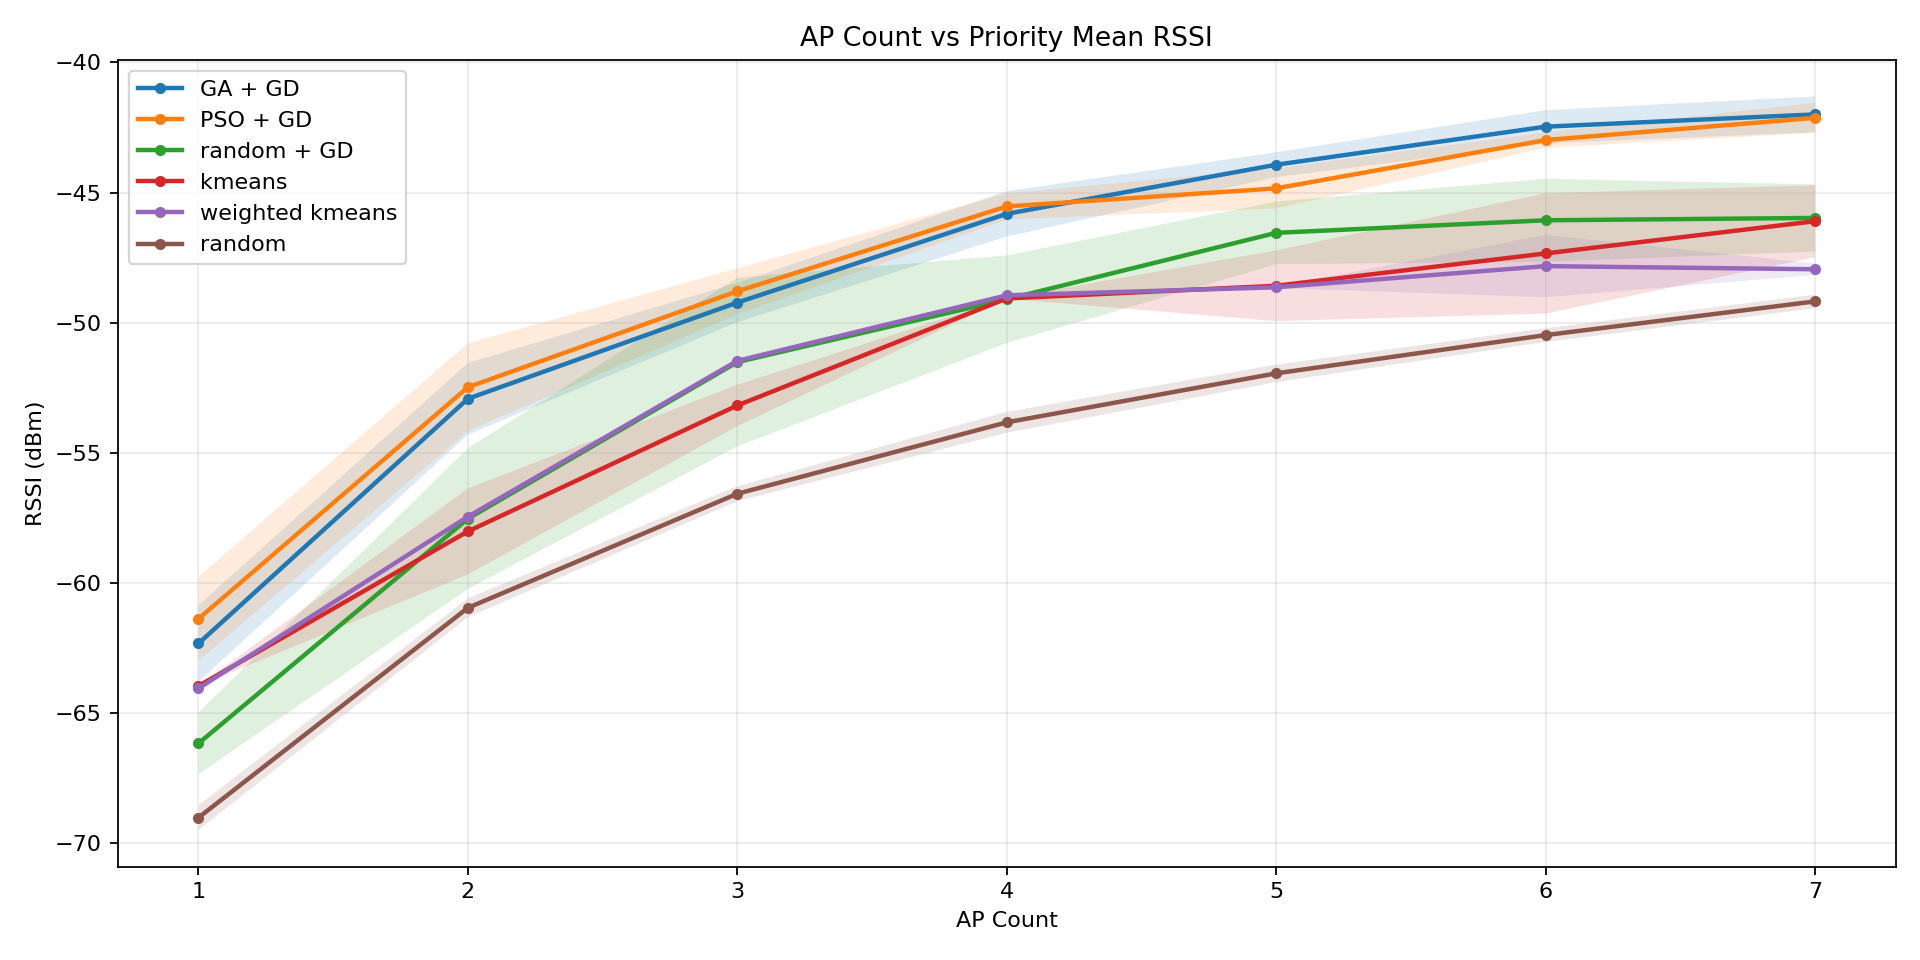

## Plot: elbow_priority_min_rss_dbm.png

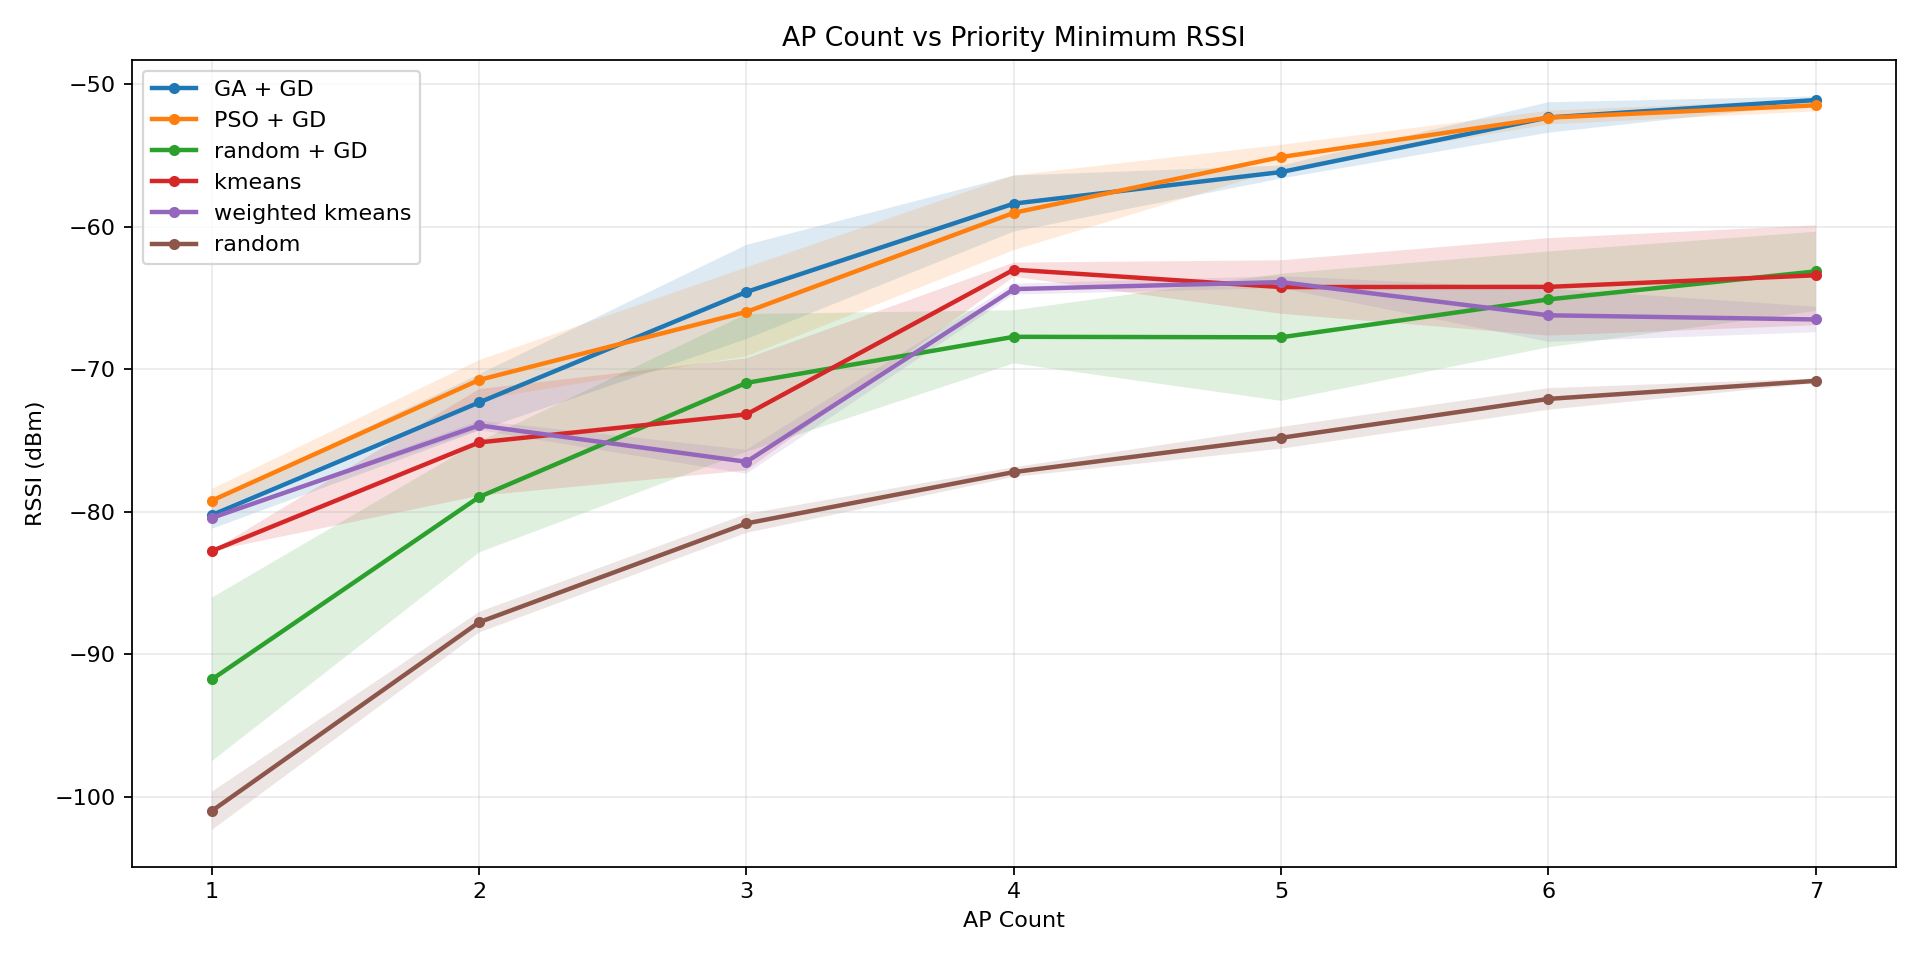

## Plot: elbow_priority_p5_rss_dbm.png

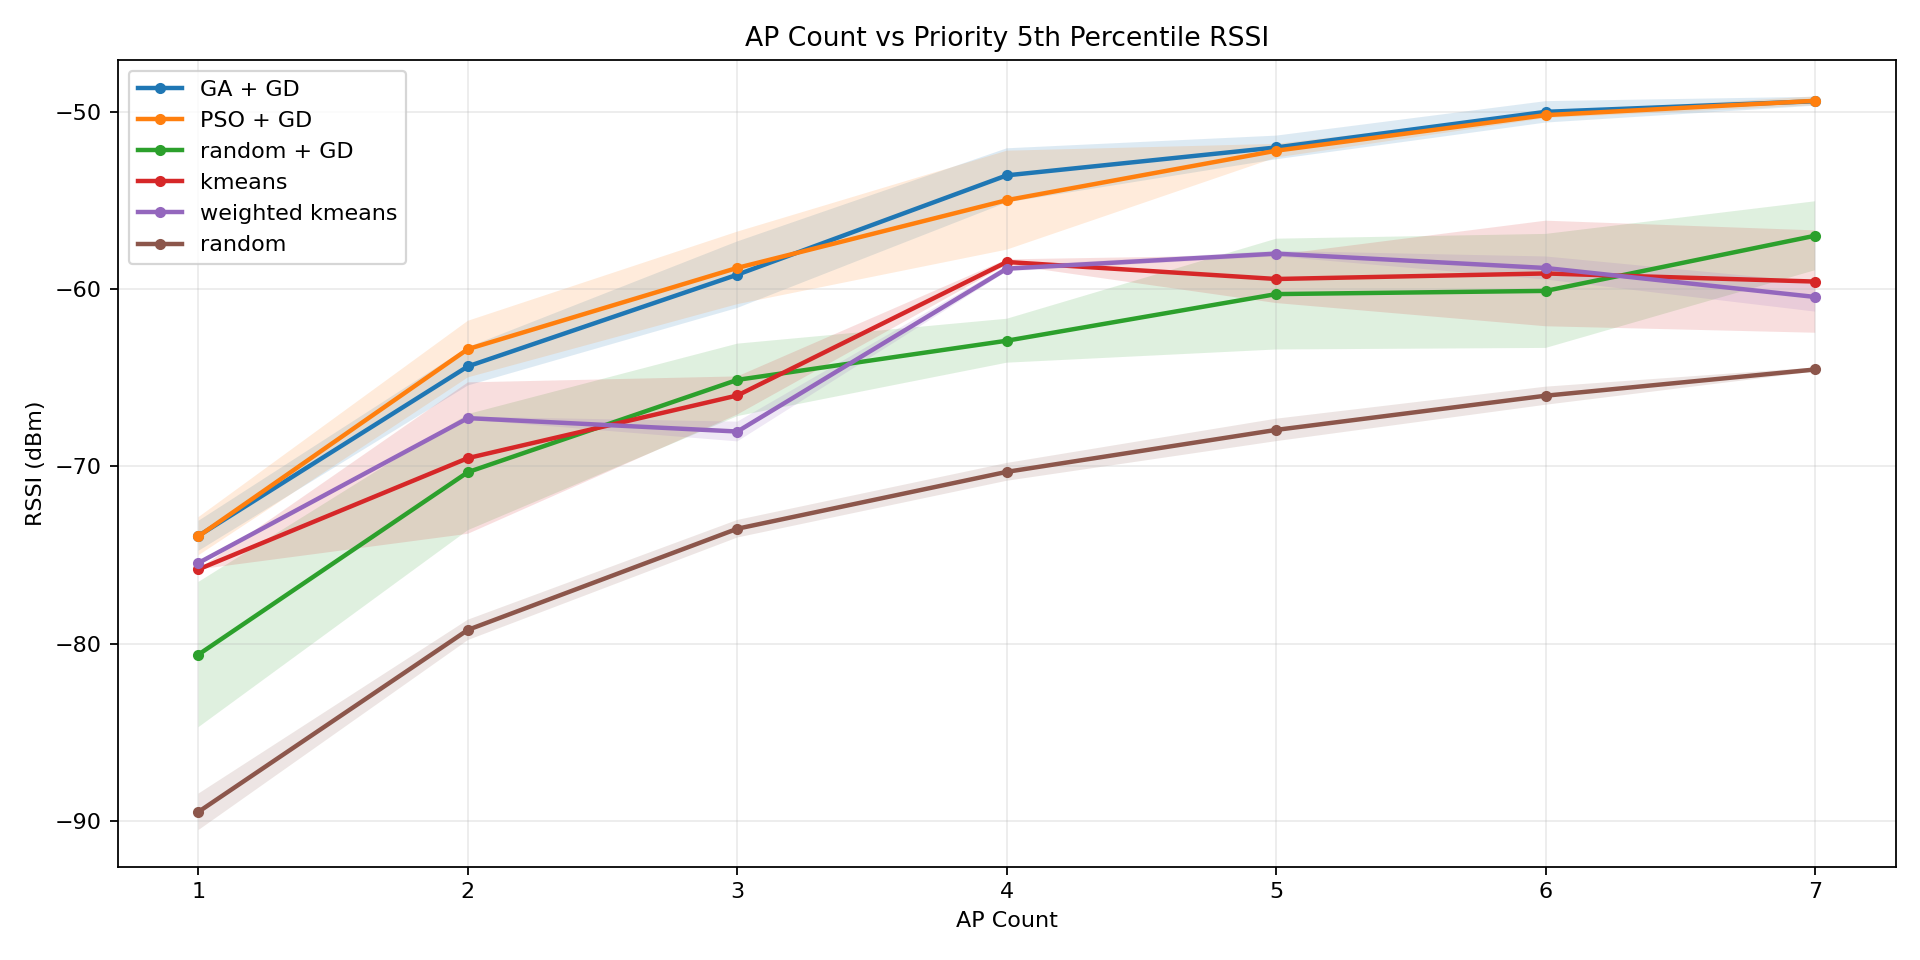

# Per-Method Tables

## Tables: AP Count vs Primary Loss (primary_loss)

### Method: GA + GD (`memetic`)

,AP Count,Mean,Std,Lower,Upper
0,1,0.395170,0.029435,0.365736,0.424605
1,2,0.109114,0.033043,0.076070,0.142157
2,3,0.000147,0.012868,-0.012721,0.013014
3,4,-0.077121,0.007286,-0.084407,-0.069834
4,5,-0.088413,0.002798,-0.091212,-0.085615
5,6,-0.097287,0.002337,-0.099624,-0.094949
6,7,-0.098976,0.000564,-0.099540,-0.098412


### Method: PSO + GD (`pso_gd`)

...

,AP Count,Mean,Std,Lower,Upper
0,1,-75.809714,0.004707,-75.814421,-75.805007
1,2,-69.537177,4.269255,-73.806431,-65.267922
2,3,-66.004749,1.073534,-67.078283,-64.931216
3,4,-58.478391,0.148034,-58.626425,-58.330357
4,5,-59.437410,1.356919,-60.794328,-58.080491
5,6,-59.125376,2.977381,-62.102757,-56.147995
6,7,-59.582518,2.886482,-62.469000,-56.696036


### Method: weighted kmeans (`weighted_kmeans`)

,AP Count,Mean,Std,Lower,Upper
0,1,-75.447924,0.001529,-75.449453,-75.446396
1,2,-67.282766,0.079075,-67.361841,-67.203691
2,3,-68.039055,0.555994,-68.595049,-67.483061
3,4,-58.853588,0.152774,-59.006362,-58.700814
4,5,-58.006963,0.152902,-58.159865,-57.854061
5,6,-58.816747,0.648870,-59.465617,-58.167877
6,7,-60.450470,0.825868,-61.276338,-59.624602


### Method: random (`random`)

,AP Count,Mean,Std,Lower,Upper
0,1,-89.485516,1.029145,-90.514661,-88.456371
1,2,-79.223832,0.574434,-79.798266,-78.649397
2,3,-73.519887,0.495179,-74.015066,-73.024708
3,4,-70.312828,0.502512,-70.815340,-69.810316
4,5,-67.946977,0.633080,-68.580057,-67.313897
5,6,-66.018348,0.509866,-66.528215,-65.508482
6,7,-64.540067,0.113845,-64.653911,-64.426222


In [12]:
# Recreate all elbow figures, display them inline, and print tables per method
elbow_data = load_elbow_data(DATA_PATH)

metric_order = [
    "primary_loss",
    "mean_rss_dbm",
    "min_rss_dbm",
    "p5_rss_dbm",
    "priority_mean_rss_dbm",
    "priority_min_rss_dbm",
    "priority_p5_rss_dbm",
]

# Optional method ordering for visual consistency across all figures and tables
method_order = ["memetic", "pso_gd", "random_gd", "kmeans", "weighted_kmeans", "random"]

saved_paths = []
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if not isinstance(metric_payload, Mapping):
        print(f"Skipping missing or invalid metric: {metric_key}")
        continue

    saved_path = plot_elbow_metric(
        metric_key=metric_key,
        metric_payload=metric_payload,
        output_dir=OUTPUT_DIR,
        with_error_band=True,
        method_order=method_order,
    )
    saved_paths.append(saved_path)
    print(f"Saved: {saved_path}")

print(f"\nGenerated {len(saved_paths)} elbow plot(s) in {OUTPUT_DIR}")

display(Markdown("# Generated Elbow Plots"))
display_saved_plots(saved_paths)

display(Markdown("# Per-Method Tables"))
for metric_key in metric_order:
    metric_payload = elbow_data.get(metric_key)
    if isinstance(metric_payload, Mapping):
        display_metric_method_tables(metric_key, metric_payload, method_order=method_order)